<a href="https://colab.research.google.com/github/lexvru/TelegramBot/blob/main/01_1_first_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Предсказание продаж

### Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn import linear_model

<img src='https://drive.google.com/uc?export=view&id=1q1pSMnZVVhVeE9l2zGckBCF33BS2vKBd'>

### Загрузка данных

https://drive.google.com/file/d/1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa

In [2]:
!pip install gdown

In [3]:
!gdown '1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa' -O final1.csv

Downloading...
From: https://drive.google.com/uc?id=1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa
To: /content/final1.csv
100% 66.6M/66.6M [00:00<00:00, 157MB/s]


In [4]:
!wget 'https://drive.google.com/uc?id=1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa' -O final.csv

--2026-03-05 19:55:26--  https://drive.google.com/uc?id=1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa
Resolving drive.google.com (drive.google.com)... 74.125.196.138, 74.125.196.100, 74.125.196.101, ...
Connecting to drive.google.com (drive.google.com)|74.125.196.138|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa [following]
--2026-03-05 19:55:26--  https://drive.usercontent.google.com/download?id=1oRtvvrVUoep5nnSexngfNFEB4cin5Rsa
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 172.217.204.132, 2607:f8b0:400c:c15::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|172.217.204.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 66590855 (64M) [application/octet-stream]
Saving to: ‘final.csv’

final.csv           100%[===================>]  63.51M  93.8MB/s    in 0.7s    

2026-03-05 19:55:29 (93.8 MB/s) - 

In [5]:
df = pd.read_csv('/content/final1.csv')
df.head()

,store,dayofweek,date,sales,customers,open,promo,lat,lon
0,1,3,2018-01-01,5530,668,1,0,55.682829,37.416212
1,2,3,2018-01-01,4422,650,1,0,55.686410,37.415503
2,3,3,2018-01-01,6823,805,1,0,55.885081,37.476452
3,4,3,2018-01-01,9941,1429,1,0,55.711356,37.389027
4,5,3,2018-01-01,4253,577,1,0,55.902867,37.609132


In [6]:
df

,store,dayofweek,date,sales,customers,open,promo,lat,lon
0,1,3,2018-01-01,5530,668,1,0,55.682829,37.416212
1,2,3,2018-01-01,4422,650,1,0,55.686410,37.415503
2,3,3,2018-01-01,6823,805,1,0,55.885081,37.476452
3,4,3,2018-01-01,9941,1429,1,0,55.711356,37.389027
4,5,3,2018-01-01,4253,577,1,0,55.902867,37.609132
...,...,...,...,...,...,...,...,...,...
1016090,1111,5,2020-07-29,5723,422,1,1,55.878577,37.706292
1016091,1112,5,2020-07-29,9626,767,1,1,55.791374,37.823187
1016092,1113,5,2020-07-29,7289,720,1,1,55.756921,37.824353
1016093,1114,5,2020-07-29,27508,3745,1,1,55.798922,37.822139


- store - магазин
- dayofweek - день недели
- date - дата
- sales - продажи
- customers - клиенты
- open - открыт магазин или нет
- promo - была ли промо акция
- lat - широта
- lon - долгота

### Делаем прогноз на июль 2020 года

<img src='https://drive.google.com/uc?export=view&id=1lkMiS2f-f-DwrBkEQIEp3HBxKm2Im9zX'>

In [7]:
df['date'] < '2020-07-01'

,date
0,True
1,True
2,True
3,True
4,True
...,...
1016090,False
1016091,False
1016092,False
1016093,False


In [9]:
df['date'].min(), df['date'].max()

('2018-01-01', '2020-07-29')

In [10]:
df['date']

,date
0,2018-01-01
1,2018-01-01
2,2018-01-01
3,2018-01-01
4,2018-01-01
...,...
1016090,2020-07-29
1016091,2020-07-29
1016092,2020-07-29
1016093,2020-07-29


In [11]:
df.dtypes

,0
store,int64
dayofweek,int64
date,object
sales,int64
customers,int64
open,int64
promo,int64
lat,float64
lon,float64


In [12]:
tmp =pd.DataFrame({
    'f1':[0,1],
    'f2':[[1, 2, 3],[0, 0, 0]]
})
tmp.dtypes

,0
f1,int64
f2,object


In [13]:
df['date']=pd.to_datetime(df['date'])
df['date']

,date
0,2018-01-01
1,2018-01-01
2,2018-01-01
3,2018-01-01
4,2018-01-01
...,...
1016090,2020-07-29
1016091,2020-07-29
1016092,2020-07-29
1016093,2020-07-29


In [14]:
df['date'].min(), df['date'].max()

(Timestamp('2018-01-01 00:00:00'), Timestamp('2020-07-29 00:00:00'))

In [15]:
df['date'] < '2020-01-01'

,date
0,True
1,True
2,True
3,True
4,True
...,...
1016090,False
1016091,False
1016092,False
1016093,False


In [16]:
df[df['date'] < '2020-01-01']

,store,dayofweek,date,sales,customers,open,promo,lat,lon
0,1,3,2018-01-01,5530,668,1,0,55.682829,37.416212
1,2,3,2018-01-01,4422,650,1,0,55.686410,37.415503
2,3,3,2018-01-01,6823,805,1,0,55.885081,37.476452
3,4,3,2018-01-01,9941,1429,1,0,55.711356,37.389027
4,5,3,2018-01-01,4253,577,1,0,55.902867,37.609132
...,...,...,...,...,...,...,...,...,...
780825,1111,4,2019-12-31,0,0,0,0,55.878577,37.706292
780826,1112,4,2019-12-31,0,0,0,0,55.791374,37.823187
780827,1113,4,2019-12-31,0,0,0,0,55.756921,37.824353
780828,1114,4,2019-12-31,0,0,0,0,55.798922,37.822139


In [17]:
df_train = df[df['date'] < '2020-01-01']
df_test = df[df['date'] >= '2020-01-01']

In [19]:
df_train.head()

,store,dayofweek,date,sales,customers,open,promo,lat,lon
0,1,3,2018-01-01,5530,668,1,0,55.682829,37.416212
1,2,3,2018-01-01,4422,650,1,0,55.686410,37.415503
2,3,3,2018-01-01,6823,805,1,0,55.885081,37.476452
3,4,3,2018-01-01,9941,1429,1,0,55.711356,37.389027
4,5,3,2018-01-01,4253,577,1,0,55.902867,37.609132


In [20]:
df_test.head()

,store,dayofweek,date,sales,customers,open,promo,lat,lon
780830,1,5,2020-01-01,5509,657,1,0,55.682829,37.416212
780831,2,5,2020-01-01,4137,543,1,0,55.686410,37.415503
780832,3,5,2020-01-01,5523,698,1,0,55.885081,37.476452
780833,4,5,2020-01-01,10737,1489,1,0,55.711356,37.389027
780834,5,5,2020-01-01,4773,509,1,0,55.902867,37.609132


### Возьмем несколько признаков

In [21]:
features = [
    'store',
    'dayofweek',
    'customers',
    'open',
    'promo',
]

target = ['sales']

### Воспользуемся простым методом прогноза

<img src='https://drive.google.com/uc?export=view&id=1alUGHx-Pabz3C3xvFDHxYbgP3tsPsH1D'>

In [22]:
model = linear_model.LinearRegression()
model

LinearRegression()

### Научим нашу модель

In [25]:
features

['store', 'dayofweek', 'customers', 'open', 'promo']

In [26]:
model.fit(
    X=df_train[features],
    y=df_train[target]
)

LinearRegression()

In [27]:
df_train[features].head()

,store,dayofweek,customers,open,promo
0,1,3,668,1,0
1,2,3,650,1,0
2,3,3,805,1,0
3,4,3,1429,1,0
4,5,3,577,1,0


In [ ]:
1*coefs[0]+3*coefs[1]+1*coefs[2]+0*coefs[3]+intercept

IndexError: index 1 is out of bounds for axis 0 with size 1

In [28]:
model.coef_

array([[-1.48874683e-01, -5.89990559e+01,  6.08756451e+00,
         1.60531189e+03,  1.26267447e+03]])

In [29]:
coefs = model.coef_[0]
coefs

array([-1.48874683e-01, -5.89990559e+01,  6.08756451e+00,  1.60531189e+03,
        1.26267447e+03])

In [31]:
intercept = model.intercept_
intercept

array([383.25323854])

In [32]:
1*coefs[0] + 3*coefs[1] + 1*coefs[2] + 0*coefs[3] + intercept

array([212.19476071])

In [33]:
model.predict(df_train[features].head())


array([[ 5877.91217952],
       [ 5768.18714362],
       [ 6711.61076836],
       [10510.10214942],
       [ 5323.34831016]])

In [34]:
model.feature_names_in_

array(['store', 'dayofweek', 'customers', 'open', 'promo'], dtype=object)

In [36]:
df_train[target].head()

,sales
0,5530
1,4422
2,6823
3,9941
4,4253


In [37]:
1 * coefs[0] + 3 * coefs[1] + 668 * coefs[2] + 1 * coefs[3] + 0 * coefs[4] + intercept

array([5877.91217952])

In [38]:
1 * -1.51031308e-01 + 3 * -5.55572871e+01 + 668 * 6.07463705e+00 + 1 * 1.67556349e+03 + 0 * 1.27110167e+03 + 352.11911259

5918.717259382

In [39]:
model.predict(df_train[features].head(1))

array([[5877.91217952]])

In [ ]:
df_train[target].head(1)

,sales
0,5530


### Сделаем прогноз

<img src='https://drive.google.com/uc?export=view&id=1YUyJxrl9ZLCGCJjSK1PvAm8IeHZU7brE'>

In [ ]:
pred = model.predict(
    X=df_test[features]
)

In [ ]:
df_test[features].shape

(32335, 5)

In [ ]:
pred.shape

(32335, 1)

In [ ]:
results = pd.DataFrame(pred, columns=['pred'])
results

,pred
0,6289.001539
1,9271.497300
2,7527.925435
3,11494.512399
4,6221.576406
...,...
32330,5416.698889
32331,7512.297641
32332,7226.638668
32333,25602.264720


### Оценим точность прогноза

<img src='https://drive.google.com/uc?export=view&id=1LK0jRvKpxNar4OCCJI_XdqnYs8hxnIUU'>

In [ ]:
df_test['sales'].reset_index(drop=True)

,sales
0,4665
1,4838
2,8149
3,11543
4,4475
...,...
32330,5723
32331,9626
32332,7289
32333,27508


In [ ]:
results['target'] = df_test['sales'].reset_index(drop=True)
results

,pred,target
0,6289.001539,4665
1,9271.497300,4838
2,7527.925435,8149
3,11494.512399,11543
4,6221.576406,4475
...,...,...
32330,5416.698889,5723
32331,7512.297641,9626
32332,7226.638668,7289
32333,25602.264720,27508


In [ ]:
results['target'].sum() / results['pred'].sum()

np.float64(1.0347025941635466)

In [ ]:
results['target'].sum()

np.int64(194886651)

In [ ]:
results['pred'].sum()

np.float64(188350403.39059585)

In [ ]:
np.mean((results['target'] - results['pred']) ** 2)  # MSE

np.float64(2308053.351565448)

In [ ]:
np.sqrt(np.mean((results['target'] - results['pred']) ** 2))  # RMSE

np.float64(1519.227880064557)

In [ ]:
?mean_squared_error

In [ ]:
from sklearn.metrics import mean_squared_error, root_mean_squared_error

print(mean_squared_error(results['target'], results['pred']))  # MSE
print(np.sqrt(mean_squared_error(results['target'], results['pred'])))  # RMSE
print(root_mean_squared_error(results['target'], results['pred']))  # RMSE

2308053.351565448
1519.227880064557
1519.227880064557


In [ ]:
results['target'].median()

5989.0

#### 🧠 Упражнение

1. Создайте модель `DecisionTreeRegressor`

In [42]:
from sklearn.tree import DecisionTreeRegressor
model = DecisionTreeRegressor()
model

DecisionTreeRegressor()

2. Обучите модель на тренировочной выборке

In [48]:
model.fit(
    X=df_train[features],
    y=df_train[target]
    )

DecisionTreeRegressor()

In [46]:
model.fit(
    X=df_train[features],
    y=df_train[target]
)

DecisionTreeRegressor()

3. Сделайте предсказания на тестовой выборке

In [ ]:
pred =

4. Оцените метрику RMSE на тестовой выборке

In [ ]:

  # RMSE

791.3558398830392

##### 🧠 Упражнение (ответ)

1. Создайте модель `DecisionTreeRegressor`

In [ ]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model

DecisionTreeRegressor()

2. Обучите модель на тренировочной выборке

In [ ]:
model.fit(
    X=df_train[features],
    y=df_train[target]
)

DecisionTreeRegressor()

3. Сделайте предсказания на тестовой выборке

In [ ]:
pred = model.predict(
    X=df_test[features]
)

4. Оцените метрику RMSE на тестовой выборке

In [ ]:
from sklearn.metrics import root_mean_squared_error

root_mean_squared_error(df_test['sales'], pred)  # RMSE

791.3558398830392

## Предсказание класса


<img src="https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png"  width=800></p>

In [ ]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
iris

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [ ]:
df = pd.DataFrame(iris.data[:, :2], columns=iris.feature_names[:2])
df['target'] = iris.target
df.head()

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0


In [ ]:
df['target'].value_counts()

,count
target,
0,50
1,50
2,50


In [ ]:
df = df[df['target'] != 2]
df['target'].value_counts()

,count
target,
0,50
1,50


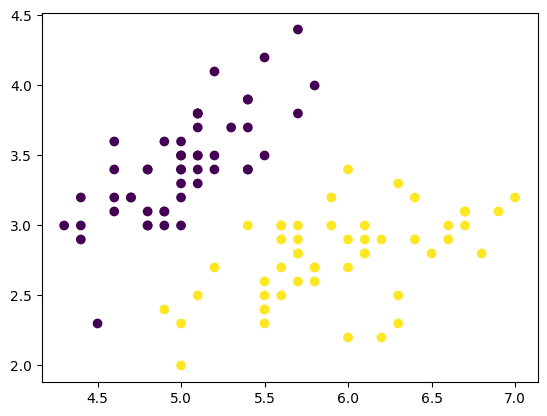

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['sepal length (cm)'], df['sepal width (cm)'], c=df['target']);

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),target
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0


In [ ]:
df = df.sample(frac=1)
df.head()

,sepal length (cm),sepal width (cm),target
14,5.8,4.0,0
77,6.7,3.0,1
65,6.7,3.1,1
64,5.6,2.9,1
79,5.7,2.6,1


In [ ]:
X = df.drop(columns=['target'])
y = df['target']

In [ ]:
n = X.shape[0]
train_frac = int(n * 0.7)
n, train_frac

(100, 70)

In [ ]:
X_train = X[:train_frac]
y_train = y[:train_frac]

X_test = X[train_frac:]
y_test = y[train_frac:]

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((70, 2), (70,), (30, 2), (30,))

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([ 0.13216928,  0.1957935 ,  0.96748648, -0.209894  , -0.08925924,
        1.11616467,  0.79645484,  0.31642826,  0.51801578, -0.01240769,
        0.11894195,  0.58825366,  1.33759319,  1.37066152,  0.60809466,
        1.21034476,  0.99142869,  0.88653373,  0.07105753,  0.0817724 ,
       -0.0363499 ,  0.65597908,  0.89063494,  0.14539662,  0.03137552,
        0.91047594,  0.87079393,  0.00492086,  0.05121653,  0.2156345 ])

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 0])

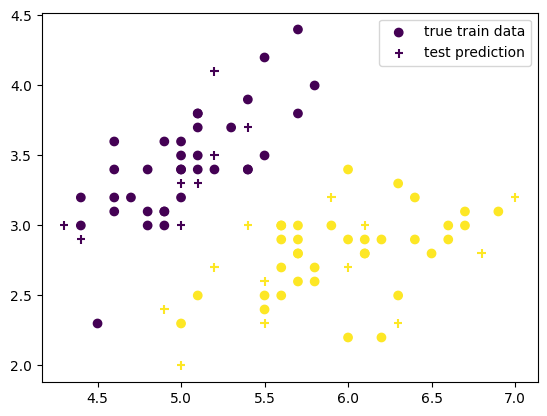

In [ ]:
plt.scatter(X_train['sepal length (cm)'], X_train['sepal width (cm)'],
            c=y_train, label='true train data', marker='o')
plt.scatter(X_test['sepal length (cm)'], X_test['sepal width (cm)'],
            c=y_pred, label='test prediction', marker='+')
plt.legend();

In [ ]:
results = pd.DataFrame()
results['true'] = y_test
results['pred'] = y_pred
results

,true,pred
27,0,0
23,0,0
53,1,1
32,0,0
44,0,0
86,1,1
90,1,1
25,0,0
84,1,1
11,0,0


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0